# Group 4 · Lab B — Order Matters: Positional Encoding, Multi-Head Attention & the Transformer Block

Lab A used a task where position was irrelevant, so plain content-based attention
with no positional encoding was enough. This lab flips that: the task depends on
WHERE tokens are, which exposes self-attention's blind spot and forces in the rest
of the Transformer machinery.

We build, from scratch:
1. Sinusoidal positional encoding -- and prove self-attention is at chance without
   it on an order-sensitive task.
2. Multi-head self-attention -- and watch different heads specialize on different
   positions.
3. The full Transformer block (multi-head attention + feed-forward + residual +
   layer norm) -- and see depth stack cleanly.

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math, random
import numpy as np
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

def seed_all(s):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)

device: cuda


## Part 1 - Positional encoding and an order-sensitive task

**The task.** Each sequence is random integer tokens. The label is 1 if the FIRST
token's value is greater than the LAST token's value, else 0. This depends entirely
on order: shuffle the sequence and the answer changes, even though the multiset of
tokens is identical.

**Why this breaks plain self-attention.** Self-attention treats its input as an
unordered set -- without position information it cannot tell which token is "first"
and which is "last", so it cannot compute the label. We fix this by adding a
**sinusoidal positional encoding** to each token embedding: a position-dependent
vector (sines and cosines at different frequencies) that tags each token with where
it sits.

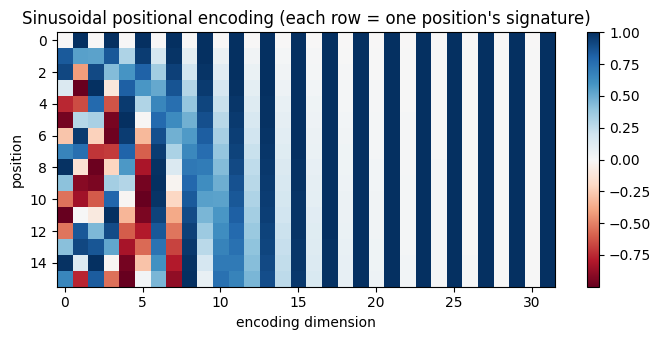

In [3]:
def positional_encoding(T, d):
    pos = torch.arange(T).unsqueeze(1).float()          # (T, 1)
    i = torch.arange(d).unsqueeze(0).float()            # (1, d)
    angle = pos / torch.pow(10000, (2 * (i // 2)) / d)
    pe = torch.zeros(T, d)
    pe[:, 0::2] = torch.sin(angle[:, 0::2])             # even dims: sine
    pe[:, 1::2] = torch.cos(angle[:, 1::2])             # odd dims: cosine
    return pe                                           # (T, d)

pe = positional_encoding(16, 32)
plt.figure(figsize=(7, 3.5))
plt.imshow(pe.numpy(), aspect="auto", cmap="RdBu")
plt.xlabel("encoding dimension"); plt.ylabel("position")
plt.title("Sinusoidal positional encoding (each row = one position's signature)")
plt.colorbar(); plt.tight_layout(); plt.show()

In [4]:
VOCAB, T = 20, 16

def make_endpoints(n, T, V=VOCAB, seed=0):
    seed_all(seed)
    X = torch.randint(0, V, (n, T))
    y = (X[:, 0] > X[:, -1]).long()      # 1 if first value > last value
    return X, y

Xs, ys = make_endpoints(1, T, seed=3)
print("sequence:", Xs[0].tolist())
print("first =", int(Xs[0,0]), " last =", int(Xs[0,-1]), " label =", int(ys[0]))

sequence: [6, 8, 17, 7, 0, 0, 0, 5, 1, 19, 14, 11, 5, 9, 6, 9]
first = 6  last = 9  label = 0




---
## Part 2 - Multi-head attention and the Transformer block

Now the real machinery, exactly as in the notes (Cards 4 and 6):

- **Multi-head self-attention**: split the model dimension into `h` heads, run
  scaled dot-product attention independently in each, concatenate, and project.
  Each head can learn to focus on a different position or relationship.
- **Transformer block**: wrap attention and a position-wise feed-forward network,
  each inside a residual connection followed by layer normalization. The residuals
  and layer norm are the Group 1/2 gradient-flow fixes, reused to keep a deep stack
  trainable.


In [5]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d, heads):
        super().__init__()
        assert d % heads == 0
        self.h = heads
        self.dk = d // heads
        self.Wq = nn.Linear(d, d); self.Wk = nn.Linear(d, d)
        self.Wv = nn.Linear(d, d); self.Wo = nn.Linear(d, d)
    def forward(self, x, return_attn=False):
        B, T, d = x.shape
        def split(t):                                   # (B,T,d) -> (B,h,T,dk)
            return t.view(B, T, self.h, self.dk).transpose(1, 2)
        Q, K, V = split(self.Wq(x)), split(self.Wk(x)), split(self.Wv(x))
        scores = Q @ K.transpose(-2, -1) / math.sqrt(self.dk)   # (B,h,T,T)
        w = F.softmax(scores, dim=-1)
        out = w @ V                                     # (B,h,T,dk)
        out = out.transpose(1, 2).contiguous().view(B, T, d)    # concat heads
        out = self.Wo(out)
        if return_attn:
            return out, w
        return out

In [6]:
class TransformerBlock(nn.Module):
    def __init__(self, d, heads, ff=64):
        super().__init__()
        self.att = MultiHeadSelfAttention(d, heads)
        self.n1 = nn.LayerNorm(d)
        self.n2 = nn.LayerNorm(d)
        self.ff = nn.Sequential(nn.Linear(d, ff), nn.ReLU(), nn.Linear(ff, d))
    def forward(self, x):
        x = self.n1(x + self.att(x))     # attention sub-layer + residual + norm
        x = self.n2(x + self.ff(x))      # feed-forward sub-layer + residual + norm
        return x

In [7]:
class Encoder(nn.Module):
    def __init__(self, V, T, d=32, heads=4, use_pe=True, n_blocks=1):
        super().__init__()
        self.embed = nn.Embedding(V, d)
        self.use_pe = use_pe
        self.register_buffer("pe", positional_encoding(T, d))
        self.blocks = nn.ModuleList([TransformerBlock(d, heads) for _ in range(n_blocks)])
        self.fc = nn.Linear(d, 2)
    def forward(self, x):
        e = self.embed(x)
        if self.use_pe:
            e = e + self.pe.unsqueeze(0)
        for b in self.blocks:
            e = b(e)
        return self.fc(e.mean(dim=1))    # mean-pool over positions, then classify

def train_eval(make_model, seed=0, epochs=15, lr=3e-3):
    seed_all(seed); model = make_model().to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr); lossf = nn.CrossEntropyLoss()
    Xtr, ytr = make_endpoints(5000, T, seed=seed)
    Xte, yte = make_endpoints(1000, T, seed=seed + 99)
    Xtr, ytr, Xte, yte = Xtr.to(device), ytr.to(device), Xte.to(device), yte.to(device)
    for ep in range(epochs):
        model.train(); perm = torch.randperm(len(ytr))
        for i in range(0, len(ytr), 128):
            idx = perm[i:i+128]; opt.zero_grad()
            loss = lossf(model(Xtr[idx]), ytr[idx]); loss.backward(); opt.step()
    model.eval()
    with torch.no_grad():
        return (model(Xte).argmax(1) == yte).float().mean().item()

print(f"{'config':30s} {'acc':>7}   (chance = 0.500)")
print(f"{'no PE, 4 heads':30s} {train_eval(lambda: Encoder(VOCAB,T,use_pe=False,heads=4)):>7.3f}")
print(f"{'with PE, 1 head':30s} {train_eval(lambda: Encoder(VOCAB,T,use_pe=True,heads=1)):>7.3f}")
print(f"{'with PE, 4 heads':30s} {train_eval(lambda: Encoder(VOCAB,T,use_pe=True,heads=4)):>7.3f}")
print(f"{'with PE, 4 heads, 2 blocks':30s} {train_eval(lambda: Encoder(VOCAB,T,use_pe=True,heads=4,n_blocks=2)):>7.3f}")

config                             acc   (chance = 0.500)
no PE, 4 heads                   0.506
with PE, 1 head                  0.952
with PE, 4 heads                 0.976
with PE, 4 heads, 2 blocks       0.995


## Part 3 - Watch the heads specialize

The task needs two specific tokens: the first and the last. With 4 heads, the model
can dedicate heads to specific positions. We train the 4-head model, then average
each head's attention weights over many examples and over all query positions, to
see which key position each head prefers. If the heads specialize, we expect one
head parked on position 0 (the first token) and another on the last position.

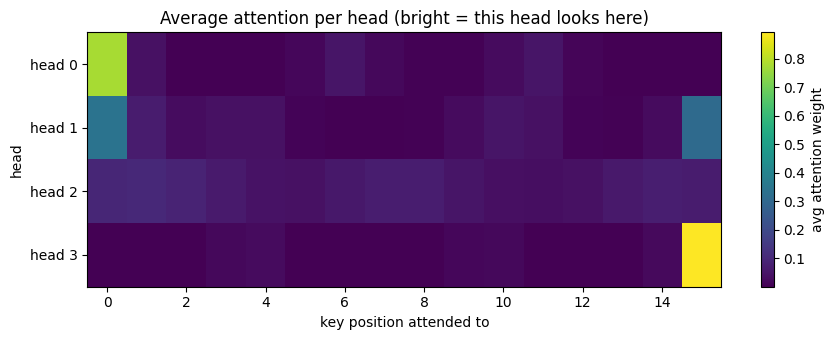

head 0: peak at position  0  (pos 0 = 0.78, pos 15 = 0.00)
head 1: peak at position  0  (pos 0 = 0.34, pos 15 = 0.31)
head 2: peak at position  1  (pos 0 = 0.09, pos 15 = 0.07)
head 3: peak at position 15  (pos 0 = 0.00, pos 15 = 0.89)


In [8]:
seed_all(0)
model = Encoder(VOCAB, T, use_pe=True, heads=4, n_blocks=1).to(device)
opt = torch.optim.Adam(model.parameters(), lr=3e-3); lossf = nn.CrossEntropyLoss()
Xtr, ytr = make_endpoints(5000, T, seed=0)
Xtr, ytr = Xtr.to(device), ytr.to(device)
for ep in range(15):
    model.train(); perm = torch.randperm(len(ytr))
    for i in range(0, len(ytr), 128):
        idx = perm[i:i+128]; opt.zero_grad()
        loss = lossf(model(Xtr[idx]), ytr[idx]); loss.backward(); opt.step()

model.eval()
Xte, _ = make_endpoints(500, T, seed=7)
e = model.embed(Xte.to(device)) + model.pe.unsqueeze(0)
_, w = model.blocks[0].att(e, return_attn=True)        # (B, heads, T, T)
head_profile = w.mean(dim=(0, 2)).detach().cpu()       # (heads, T): avg weight per key position

plt.figure(figsize=(9, 3.5))
plt.imshow(head_profile.numpy(), aspect="auto", cmap="viridis")
plt.yticks(range(4), [f"head {i}" for i in range(4)])
plt.xlabel("key position attended to"); plt.ylabel("head")
plt.title("Average attention per head (bright = this head looks here)")
plt.colorbar(label="avg attention weight")
plt.tight_layout(); plt.show()

for h in range(4):
    prof = head_profile[h].numpy()
    print(f"head {h}: peak at position {prof.argmax():2d}  "
          f"(pos 0 = {prof[0]:.2f}, pos {T-1} = {prof[-1]:.2f})")

## Lab B - concept check

**Q1. Without positional encoding the model sat at 0.506 on a task it clearly has
the capacity to solve (the same architecture hits 0.95+ once PE is added). Explain
precisely why the accuracy is pinned at chance, not merely "lower".**

Self-attention is permutation-equivariant: permute the input positions and the
output positions permute identically, with the same values. The classifier then
mean-pools over positions, which is permutation-invariant, so the model's output is
literally unchanged under any reordering of the input. But the label -- "is the
first value greater than the last" -- flips under reordering. A sequence and its
first-last swap have the same bag of tokens but opposite labels, and the model is
mathematically forced to give them the same prediction. It therefore cannot do
better than guessing the base rate, which is 0.5. This is not a trainability
problem that more epochs or capacity could fix; it is an invariance the architecture
imposes until position information breaks the symmetry. Positional encoding breaks
it by making each position's representation distinct, so reordering changes the
inputs and the model can respond.

**Q2. The heads specialized -- one on the first position, one on the last. Was the
model told to do this, and what in the setup made this the solution it found?**

Nothing told it to; the specialization is emergent, discovered by gradient descent
because it is the most efficient way to reduce the loss on this task. The label
depends on exactly two positions, so a representation that cleanly extracts the
first and last tokens makes the final linear comparison trivial, and any parameter
configuration that produces that representation gets low loss. Multiple heads with
independent Q/K/V projections give the model the degrees of freedom to route one
head to position 0 and another to position T-1 via the positional encodings, so the
gradient naturally pushes it there. The deeper point is that head roles are a
consequence of task structure and optimization pressure, not a designed assignment
-- which is why interpreting real Transformers' heads is an empirical exercise: you
discover what they learned to do, you do not read it off the architecture.

**Q3. The Transformer block wraps attention and the feed-forward network each in
"residual then layer norm". Both residuals and normalization first appeared in
Groups 1-2 for convolutional networks. Why do they reappear here, and what would a
deep stack of attention blocks do without them?**

They reappear because the problem they solve -- training signal degrading as it
passes through many layers -- is about depth in general, not about convolution
specifically, and a Transformer is a deep stack. Residual connections give the
gradient a direct additive path around each sub-layer, so a deep stack of blocks can
be trained without the gradient vanishing as it backpropagates through every
attention and feed-forward layer; this is the same skip-connection cure that healed
the deep CNN in the Gradient Autopsy, now holding up a deep attention network. Layer
normalization keeps each token's activations well-scaled from layer to layer,
preventing the drift and saturation that destabilize deep training -- the BatchNorm
lesson of Group 2, using the per-token variant because it does not depend on batch
or sequence-length statistics. Without them, a deep stack would be badly conditioned:
gradients would shrink or blow up across the layers and activations would drift, so
the network would train poorly or not at all past a few blocks. Attention solves
vanishing gradients across sequence distance; residuals and layer norm solve
vanishing gradients across stack depth. Both are needed, and they are the same ideas
from earlier groups reused.